In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)
print("All imports successful!")

All imports successful!


In [3]:
train_tx = pd.read_csv('/home/aniketnerali16/fraud_detection/data/train_transaction.csv')
train_id = pd.read_csv('/home/aniketnerali16/fraud_detection/data/train_identity.csv')

df = train_tx.merge(train_id, on='TransactionID', how='left')

print("Transaction data shape :", train_tx.shape)
print("Identity data shape: ", train_id.shape)
print("Merged data  shape:", df.shape)


Transaction data shape : (590540, 394)
Identity data shape:  (144233, 41)
Merged data  shape: (590540, 434)


In [4]:
print("=== First 5 rows ===")
display(df.head())


print("=== Data types ===")
print(df.dtypes.value_counts())

print("\n=== Memory Usage ===")
print(f"{df.memory_usage(deep=True).sum()/ 1e9:.2f} GB")

=== First 5 rows ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


=== Data types ===
float64    399
str         31
int64        4
Name: count, dtype: int64

=== Memory Usage ===
2.69 GB


=== Fraud distribution ===
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%
Legitimate: 96.50%


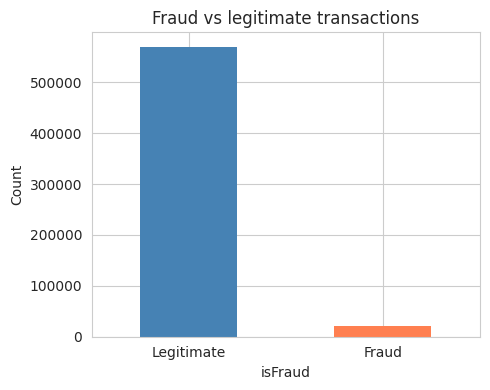

In [5]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print("=== Fraud distribution ===")
print(fraud_counts)
print(f"\nFraud rate: {fraud_pct[1]:.2f}%")
print(f"Legitimate: {fraud_pct[0]:.2f}%")

plt.figure(figsize=(5, 4))
fraud_counts.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='none')
plt.title('Fraud vs legitimate transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Columns with missing values : 414 out of 434

 Top 20 missing:


,Missing count,Missing %
id_24,585793,99.2
id_25,585408,99.1
id_26,585377,99.1
id_21,585381,99.1
id_22,585371,99.1
id_23,585371,99.1
id_08,585385,99.1
id_07,585385,99.1
id_27,585371,99.1
dist2,552913,93.6


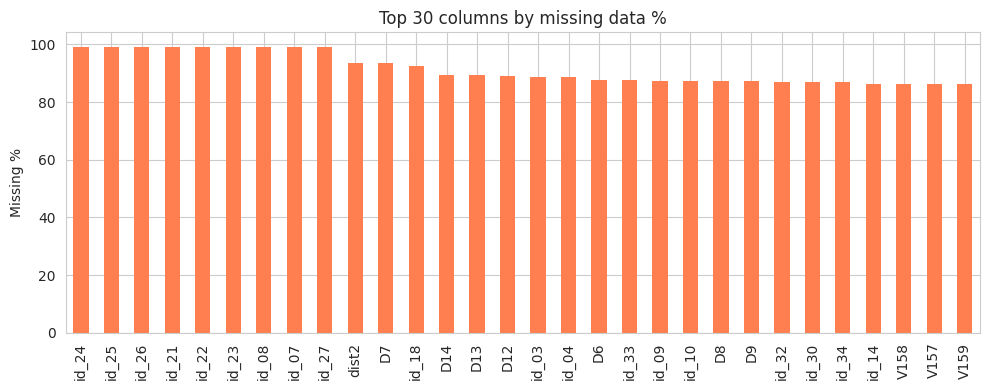

In [6]:
missing = df.isnull().sum()
missing_pct = ( missing/len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing count' : missing,
    'Missing %' : missing_pct
}).sort_values('Missing %', ascending= False)

missing_df = missing_df[missing_df['Missing count'] > 0]


print(f"Columns with missing values : {len(missing_df)} out of {df.shape[1]}")
print(f"\n Top 20 missing:")
display(missing_df.head(20))


plt.figure(figsize=(10, 4))
missing_df['Missing %'].head(30).plot(kind='bar', color='coral', edgecolor='none')
plt.title('Top 30 columns by missing data %')
plt.ylabel('Missing %')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


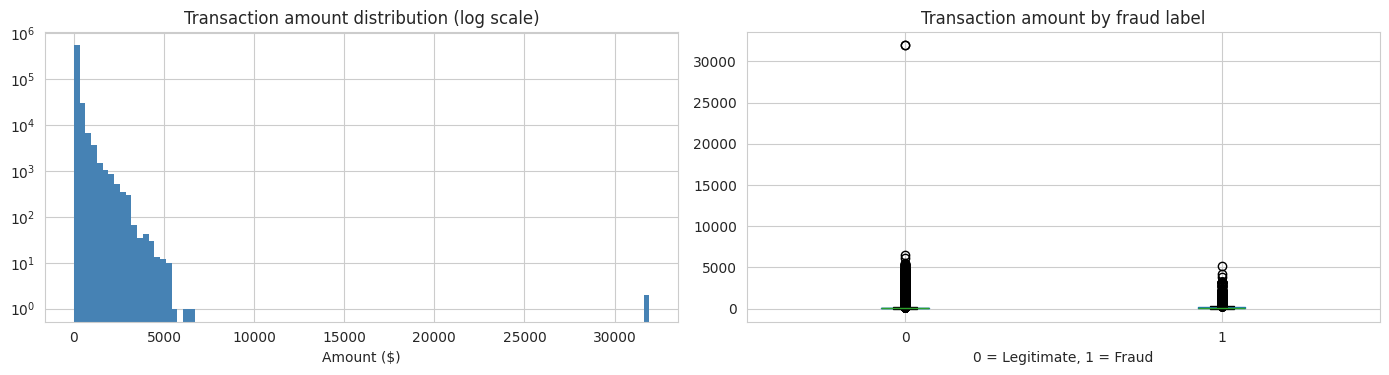

=== Transaction amount stats by fraud label ===


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,5191.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
df['TransactionAmt'].hist(ax=axes[0], bins=100, color='steelblue', 
                           edgecolor='none', log=True)
axes[0].set_title('Transaction amount distribution (log scale)')
axes[0].set_xlabel('Amount ($)')

# Fraud vs legitimate amounts
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1])
axes[1].set_title('Transaction amount by fraud label')
axes[1].set_xlabel('0 = Legitimate, 1 = Fraud')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("=== Transaction amount stats by fraud label ===")
display(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

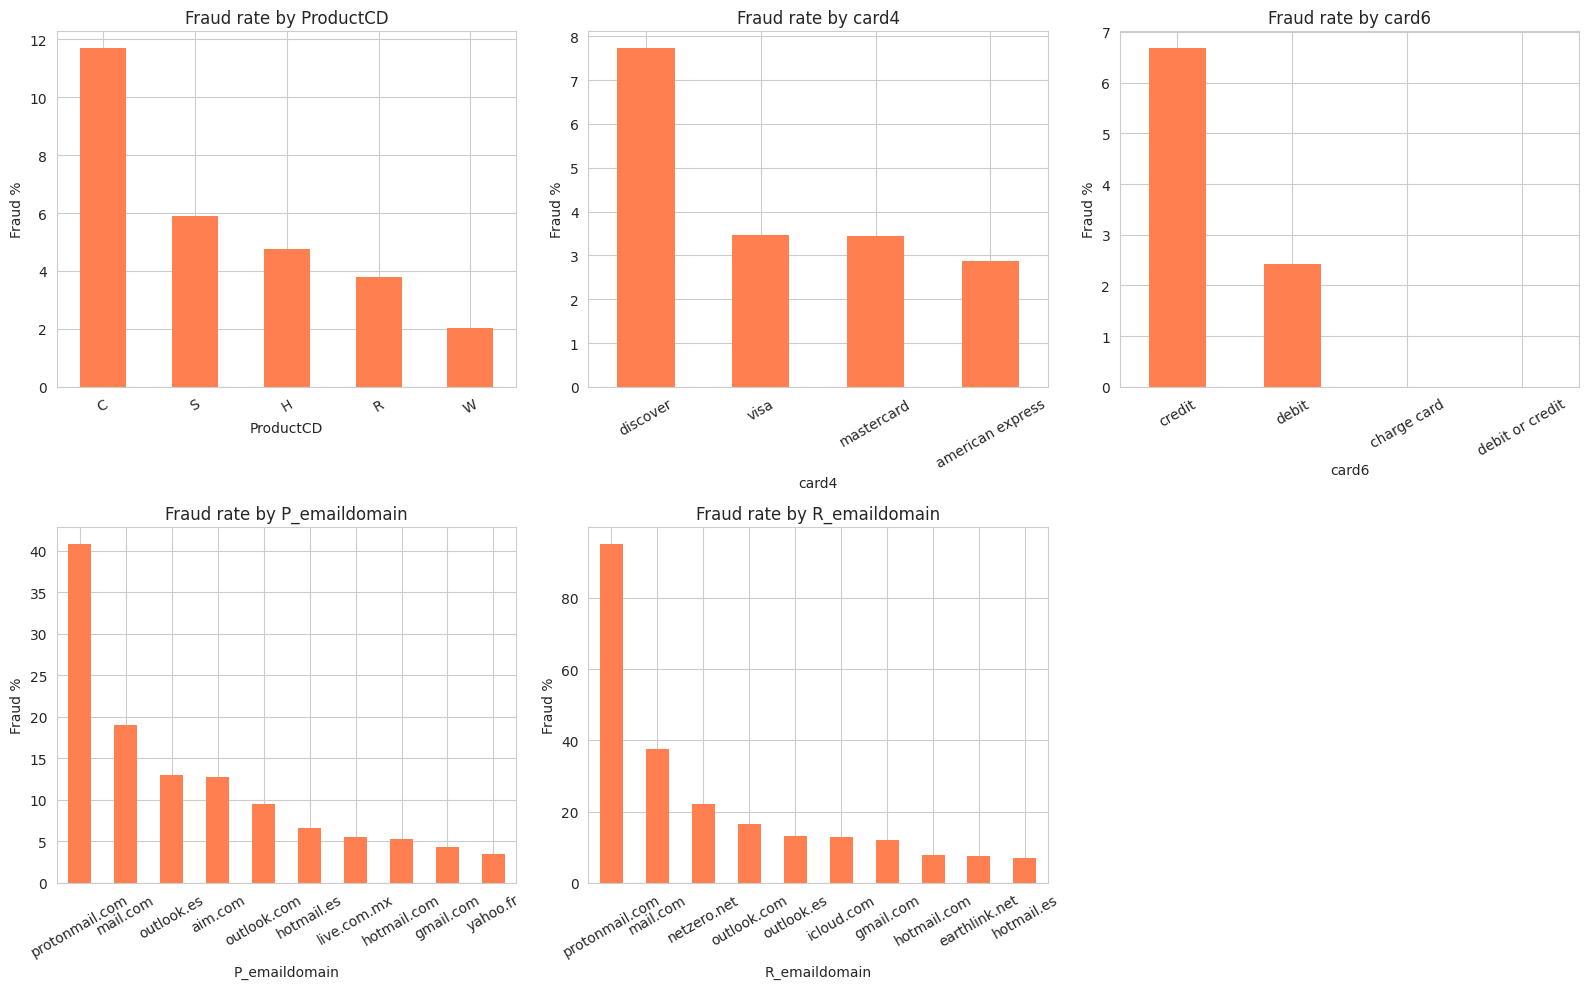

In [8]:
cat_features = ['ProductCD' , 'card4', 'card6','P_emaildomain', 'R_emaildomain' ]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), cat_features) : 
    if col in df.columns:
        fraud_rate = (
            df.groupby(col)['isFraud']
            .mean()
            .mul(100)
            .sort_values(ascending=False)
            .head(10)
        )
        fraud_rate.plot(kind='bar', ax =ax, color ='coral', edgecolor = 'none')
        ax.set_title(f'Fraud rate by {col}')
        ax.set_ylabel('Fraud %')
        ax.tick_params(axis='x', rotation = 30)


axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()



/tmp/ipykernel_18207/414158168.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = (df['TransactionDT'] / 3600 % 24).astype(int)
/tmp/ipykernel_18207/414158168.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day']  = (df['TransactionDT'] / (3600 * 24) % 7).astype(int)


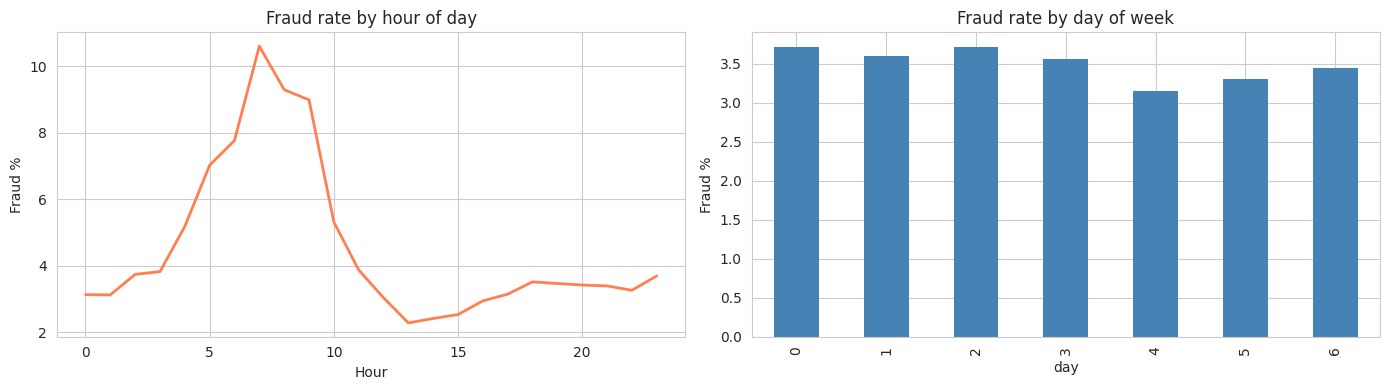

In [9]:
# TransactionDT is seconds from a reference point
df['hour'] = (df['TransactionDT'] / 3600 % 24).astype(int)
df['day']  = (df['TransactionDT'] / (3600 * 24) % 7).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fraud rate by hour
hourly = df.groupby('hour')['isFraud'].mean() * 100
hourly.plot(kind='line', ax=axes[0], color='coral', linewidth=2)
axes[0].set_title('Fraud rate by hour of day')
axes[0].set_ylabel('Fraud %')
axes[0].set_xlabel('Hour')

# Fraud rate by day
daily = df.groupby('day')['isFraud'].mean() * 100
daily.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='none')
axes[1].set_title('Fraud rate by day of week')
axes[1].set_ylabel('Fraud %')

plt.tight_layout()
plt.show()

In [10]:
def engineer_features(df) : 


    # 1. Transaction amount features
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    df['TransactionAmt_decimal'] = df ['TransactionAmt'] - df['TransactionAmt'].astype(int)
    df['isRoundAmount']  = (df['TransactionAmt_decimal'] == 0).astype(int)

    # Time features
    df['hour'] = (df['TransactionDT'] / 3600 % 24).astype(int)
    df['day'] = (df['TransactionDT'] / (3600*24) % 7).astype(int)
    df['isWeekend'] = (df['day'] >= 5).astype(int)
    df['isNightTime'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

    # 3. Card features
    df['card_combo'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)

    # 4. Email Domain Features

    df['P_email_domain_match'] = (
        df['P_emaildomain'] == df['R_emaildomain']
    ).astype(int)


    df['P_isGmail'] = df['P_emaildomain'].str.contains(
        'gmail', na =False).astype(int)
    df['P_isYahoo'] = df['P_emaildomain'].str.contains(
        'yahoo', na = False).astype(int)
    

    # 5. Transaction valocity per card
    # Hom many transactions has this card made ?

    card_counts = df.groupby('card1')['TransactionID'].transform('count')
    df['card1_transaction_count'] = card_counts


    # 6. Average transaction amount per card 
    card_avg = df.groupby('card1')['TransactionAmt'].transform('mean')
    df['card1_avg_amount'] = card_avg


    #7. how much does this transaction deviate from cards average 
    df['amt_vs_card_avg'] = df['TransactionAmt'] / (df['card1_avg_amount']+ 1)

    # 8. Identity features
    if 'id_31' in df.columns:
        df['isMobile'] = df['id_31'].str.contains(
            'mobile|android|ios|samsung', na=False, case=False).astype(int)
        

    return df

df = engineer_features(df)

print("Feature engineering done!")
print(f"New shape: {df.shape}")
    

/tmp/ipykernel_18207/3137737374.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
/tmp/ipykernel_18207/3137737374.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TransactionAmt_decimal'] = df ['TransactionAmt'] - df['TransactionAmt'].astype(int)
/tmp/ipykernel_18207/3137737374.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

Feature engineering done!
New shape: (590540, 449)


/tmp/ipykernel_18207/3137737374.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['isMobile'] = df['id_31'].str.contains(


In [11]:
# Drop columns with more than 50% missing
threshold = 0.5
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} high-missing columns")
print(f"Shape after dropping: {df.shape}")

# Encode remaining categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nEncoding {len(cat_cols)} categorical columns...")

le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].fillna('unknown')
    df[col] = le.fit_transform(df[col].astype(str))

# Fill remaining numeric nulls with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Encoding done!")
print(f"Final shape: {df.shape}")

Dropped 214 high-missing columns
Shape after dropping: (590540, 235)

Encoding 10 categorical columns...


/tmp/ipykernel_18207/1724799081.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Encoding done!
Final shape: (590540, 235)


In [12]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nFraud ratio: {y_train.mean() * 100:.2f}%")
print("\nNo SMOTE needed — using class_weight in models instead")


Training set: (472432, 233)
Test set:     (118108, 233)

Class distribution in training set:
isFraud
0    455902
1     16530
Name: count, dtype: int64

Fraud ratio: 3.50%

No SMOTE needed — using class_weight in models instead


In [13]:
import json

# Save processed data directly — no SMOTE
X_train.to_csv('/home/aniketnerali16/fraud_detection/data/X_train.csv', index=False)
X_test.to_csv('/home/aniketnerali16/fraud_detection/data/X_test.csv', index=False)
y_train.to_csv('/home/aniketnerali16/fraud_detection/data/y_train.csv', index=False)
y_test.to_csv('/home/aniketnerali16/fraud_detection/data/y_test.csv', index=False)

# Save feature columns for later phases
with open('/home/aniketnerali16/fraud_detection/data/feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

print("Saved all files!")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("Phase 1 complete!")

Saved all files!
X_train: (472432, 233)
X_test:  (118108, 233)
Phase 1 complete!
